In [1]:
# Important Variables

In [2]:
extraTreeSelectionN_Estimators=50
PCAThreshold = 0.005
input_folder = "../Packet Flows Conversion (.txt to .csv)/Converted CSVs"
attackType = "Trojan"
energyPercentage = "40"
attackDuration = "10ms"

In [3]:
# Data Preparation

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import glob

pd.set_option('display.max_rows', 500, 'display.max_columns', 100)

In [5]:
## Make Normal Dataset

In [6]:
normal_pattern = os.path.join(input_folder, f"Normal_{energyPercentage}_*.csv")
normal_files = glob.glob(normal_pattern)

In [7]:
if normal_files:
    # Generator expression to load files directly into a list for concatenation
    dtNormal = pd.concat((pd.read_csv(f) for f in normal_files), ignore_index=True)
    print(f"dtNormal created: Combined {len(normal_files)} files.")
else:
    dtNormal = pd.DataFrame()
    print("No matching Normal files found.")

dtNormal created: Combined 4 files.


In [8]:
## Make Malicous Dataset

In [9]:
duration_suffix = "*" if str(attackDuration).upper() == 'ALL' else attackDuration

In [10]:
malicious_pattern = os.path.join(input_folder, f"{attackType}_{energyPercentage}_*_{duration_suffix}_intervals.csv")
malicious_files = glob.glob(malicious_pattern)

In [11]:
if malicious_files:
    # Combine matching malicious files into one DataFrame
    dtMalicious = pd.concat((pd.read_csv(f) for f in malicious_files), ignore_index=True)
    print(f"dtMalicious created: Combined {len(malicious_files)} files.")
else:
    dtMalicious = pd.DataFrame()
    print("No matching Malicious files found.")

dtMalicious created: Combined 4 files.


In [12]:
#dtMalicious = dtMalicious.drop(["Date", "Data", "Packet #"], axis=1)
#dtNormal = dtNormal.drop(["Date", "Data", "Packet #"], axis=1)
#dtNormal['ID'] = dtNormal['ID'].astype(str).str.replace('BB', '00')
#dtMalicious['ID'] = dtMalicious['ID'].astype(str).str.replace('BB', '00')
dtNormal = dtNormal.apply(pd.to_numeric, errors = "coerce")
dtMalicious = dtMalicious.apply(pd.to_numeric, errors = "coerce")
dtNormal = dtNormal.fillna(0)
dtMalicious = dtMalicious.fillna(0)
dtNormal = dtNormal.astype(float)
dtMalicious = dtMalicious.astype(float)

In [13]:
print("\n--- Workspace Summary ---")
print(f"dtNormal Shape:    {dtNormal.shape}")
print(f"dtMalicious Shape: {dtMalicious.shape}")


--- Workspace Summary ---
dtNormal Shape:    (5658, 9)
dtMalicious Shape: (5406, 9)


In [14]:
## Generate x and y

In [15]:
X = pd.concat([dtNormal, dtMalicious], ignore_index=True)
y = np.concatenate([np.zeros(len(dtNormal)), np.ones(len(dtMalicious))])

print(f"X Shape:    {X.shape}")
print(f"y Shape:    {y.shape}")

X Shape:    (11064, 9)
y Shape:    (11064,)


In [16]:
## Apply label encoder

In [17]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

In [18]:
print(y)

[0 0 0 ... 1 1 1]


In [19]:
# Pre-Test: Logistic Regression with No Reduction

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0, stratify=y)

In [21]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [22]:
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression(random_state = 0, max_iter=2000)
classifier.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",0
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multic

In [23]:
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score
y_pred = classifier.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print(cm)
print('Accuracy: ', accuracy_score(y_test, y_pred))
print('Precision: ',precision_score(y_test, y_pred))
print('Recall: ',recall_score(y_test, y_pred))
print('F1-Score',f1_score(y_test, y_pred))

[[820 312]
 [730 351]]
Accuracy:  0.5291459557162224
Precision:  0.5294117647058824
Recall:  0.32469935245143383
F1-Score 0.4025229357798165


In [24]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

k_fold = StratifiedKFold(n_splits = 5)

kfoldscores = cross_val_score(classifier, X_test, y_test, cv=k_fold)

print("Average CV scores: ", kfoldscores.mean())

Average CV scores:  0.525963453622463


Model 1 AUC score: 0.524540488946565


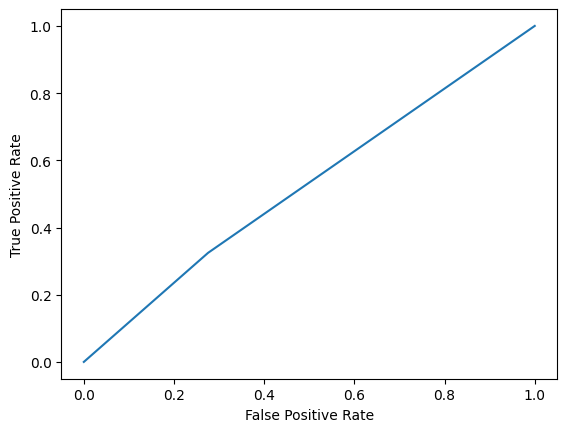

In [25]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score

def plot_roc_curve(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    plt.plot(fpr, tpr)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')

plot_roc_curve(y_test, y_pred)
print(f'Model 1 AUC score: {roc_auc_score(y_test, y_pred)}')
aucScore = roc_auc_score(y_test, y_pred)

In [26]:
# Feature Selection

In [27]:
## Extra Trees

In [28]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.feature_selection import SelectFromModel

clf = ExtraTreesClassifier(n_estimators=extraTreeSelectionN_Estimators)
clf = clf.fit(X, y)
clf.feature_importances_

array([0.14903517, 0.15037469, 0.19796392, 0.        , 0.02225377,
       0.07920337, 0.07966277, 0.14975243, 0.17175388])

In [29]:
model = SelectFromModel(clf, prefit=True)

In [30]:
model = SelectFromModel(clf, prefit=True)
feature_idx = model.get_support()
feature_name = X.columns[feature_idx]
feature_name

Index(['Rel Start (s)', 'Rel End (s)', 'Interval Duration', 'Max Data Gap',
       'Min Data Gap'],
      dtype='str')

In [31]:
new_X = model.transform(X)
X = pd.DataFrame(new_X, columns=feature_name)

/home/berei/.local/lib/python3.14/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


In [32]:
X.shape

(11064, 5)

In [33]:
# Prepare Post-Reduction Data

In [34]:
## Test/Train Data

In [35]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=1, stratify=y)

In [36]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [37]:
# Post-Reduciton Test

In [38]:
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression(random_state = 0)
classifier.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",0
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multic

In [39]:
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score
y_pred = classifier.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print(cm)
print('Accuracy: ', accuracy_score(y_test, y_pred))
print('Precision: ',precision_score(y_test, y_pred))
print('Recall: ',recall_score(y_test, y_pred))
print('F1-Score',f1_score(y_test, y_pred))

[[840 292]
 [733 348]]
Accuracy:  0.5368278355173972
Precision:  0.54375
Recall:  0.32192414431082333
F1-Score 0.4044160371876816


In [40]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

k_fold = StratifiedKFold(n_splits = 5)

kfoldscores = cross_val_score(classifier, X_test, y_test, cv=k_fold)

print("Average CV scores: ", kfoldscores.mean())

Average CV scores:  0.5250727761151344


Model 1 AUC score: 0.5319868071377438


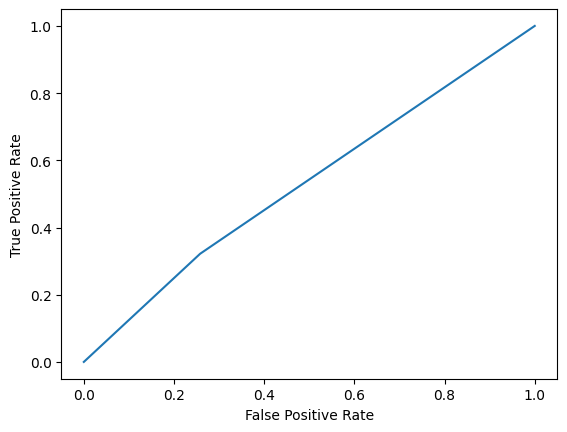

In [41]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score

def plot_roc_curve(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    plt.plot(fpr, tpr)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')

plot_roc_curve(y_test, y_pred)
print(f'Model 1 AUC score: {roc_auc_score(y_test, y_pred)}')
aucScore = roc_auc_score(y_test, y_pred)

In [42]:
# Export Data for Training

In [43]:
exportX_train = pd.DataFrame(X_train, columns=feature_name)
exportX_test = pd.DataFrame(X_test, columns=feature_name)
exporty_train = pd.DataFrame(y_train)
exporty_test = pd.DataFrame(y_test)

In [44]:
import os

# Define the base naming scheme
base_name = f"{attackType}_{energyPercentage}_{attackDuration}"

# List of target directories
directories = [
    'Training Data/X_train',
    'Training Data/X_test',
    'Training Data/y_train',
    'Training Data/y_test'
]

# Create folders if they don't exist
for folder in directories:
    os.makedirs(folder, exist_ok=True)

# Export with the naming scheme + suffix
exportX_train.to_csv(f'Training Data/X_train/{base_name}_X_train.csv', index=False)
exportX_test.to_csv(f'Training Data/X_test/{base_name}_X_test.csv', index=False)
exporty_train.to_csv(f'Training Data/y_train/{base_name}_y_train.csv', index=False)
exporty_test.to_csv(f'Training Data/y_test/{base_name}_y_test.csv', index=False)

print(f"Successfully exported data for {base_name}")

Successfully exported data for Trojan_40_10ms
